In [215]:
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [216]:
diabetes = load_diabetes(scaled=False)

print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [217]:
df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
df["target"] = diabetes.target
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.00,157.0,93.2,38.0,4.00,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.00,183.0,103.2,70.0,3.00,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.00,156.0,93.6,41.0,4.00,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.00,198.0,131.4,40.0,5.00,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.00,192.0,125.4,52.0,4.00,4.2905,80.0,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,60.0,2.0,28.2,112.00,185.0,113.8,42.0,4.00,4.9836,93.0,178.0
438,47.0,2.0,24.9,75.00,225.0,166.0,42.0,5.00,4.4427,102.0,104.0
439,60.0,2.0,24.9,99.67,162.0,106.6,43.0,3.77,4.1271,95.0,132.0
440,36.0,1.0,30.0,95.00,201.0,125.2,42.0,4.79,5.1299,85.0,220.0


array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'bp'}>, <Axes: title={'center': 's1'}>,
        <Axes: title={'center': 's2'}>],
       [<Axes: title={'center': 's3'}>, <Axes: title={'center': 's4'}>,
        <Axes: title={'center': 's5'}>],
       [<Axes: title={'center': 's6'}>,
        <Axes: title={'center': 'target'}>, <Axes: >]], dtype=object)

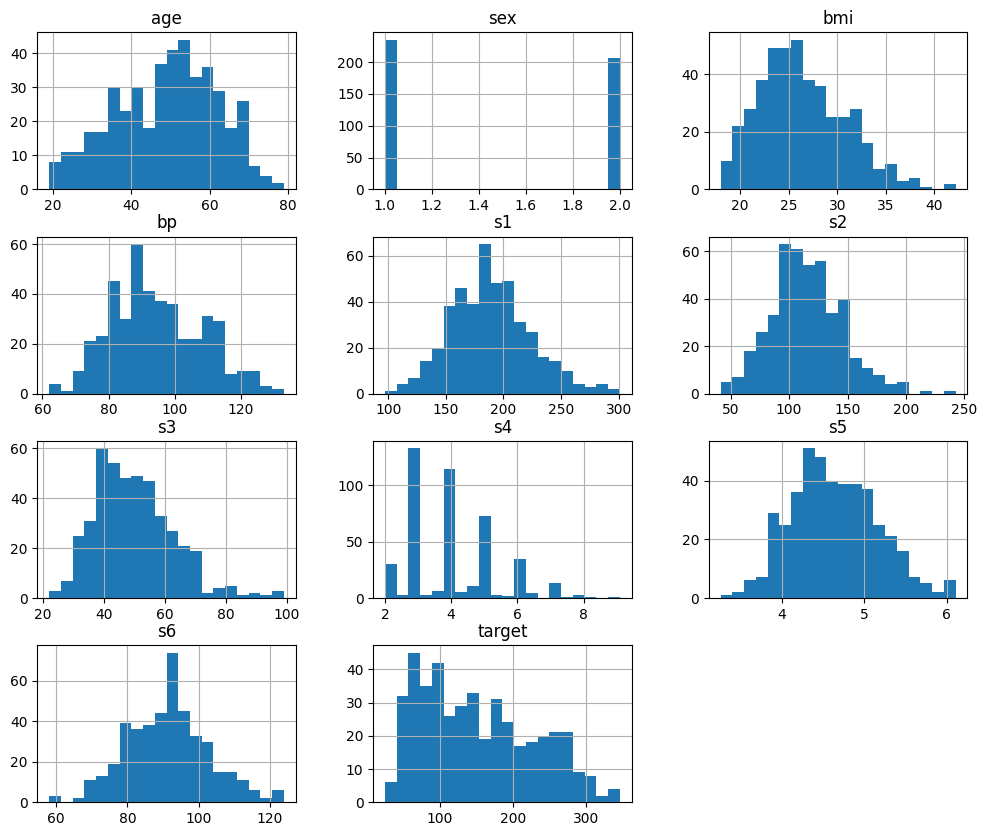

In [218]:
df.hist(bins=20, figsize=(12, 10))

In [219]:
corr_matrix = df.corr()
corr_matrix

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


<Axes: >

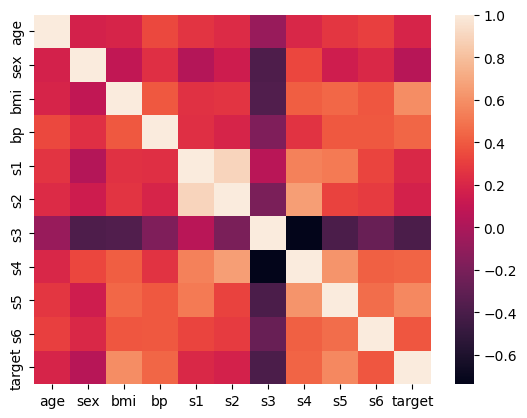

In [220]:
sns.heatmap(corr_matrix)

<Axes: >

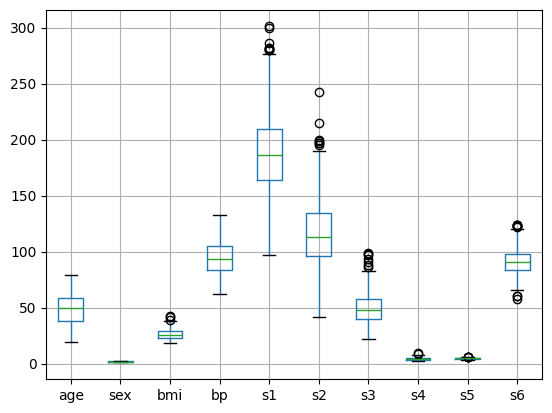

In [221]:
df.iloc[:, :-1].boxplot()

In [222]:
_X = df.iloc[:, :-1].values
_Y = df.iloc[:, -1:].values
print(_X.shape)
print(_Y.shape)

(442, 10)
(442, 1)


In [223]:
_X_train, _X_test, _Y_train, _Y_test = train_test_split(
    _X, _Y, test_size=0.3, random_state=0
)
print(_X_train.shape)
print(_X_test.shape)
print(_Y_train.shape)
print(_Y_test.shape)

(309, 10)
(133, 10)
(309, 1)
(133, 1)


In [224]:
scX = StandardScaler()
X_train = scX.fit_transform(_X_train)
X_test = scX.transform(_X_test)

scY = StandardScaler()
Y_train = scY.fit_transform(_Y_train)
Y_test = scY.transform(_Y_test)

<Axes: >

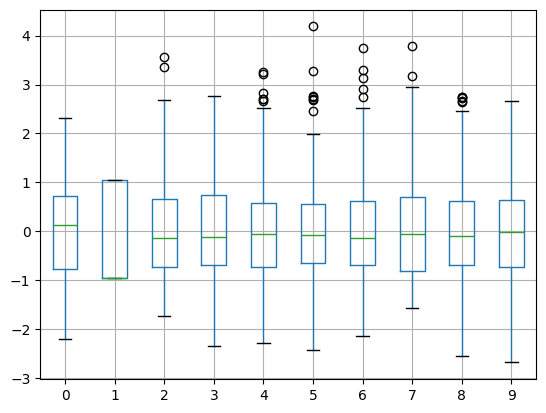

In [225]:
pd.DataFrame(data=X_train).boxplot()

In [226]:
X_train_pt = torch.from_numpy(X_train).float()
X_test_pt = torch.from_numpy(X_test).float()
Y_train_pt = torch.from_numpy(Y_train).float()
Y_test_pt = torch.from_numpy(Y_test).float()

In [227]:
num_features = _X.shape[1]
num_outputs = _Y.shape[1]
print(num_features, num_outputs)

10 1


In [228]:
class MyModel(nn.Module):
    def __init__(self, num_features, num_outputs):
        super(MyModel, self).__init__()
        self.fc1 = nn.Linear(num_features, 24)
        self.fc2 = nn.Linear(24, 12)
        self.fc3 = nn.Linear(12, 6)
        self.fc4 = nn.Linear(6, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [229]:
model = MyModel(num_features=num_features, num_outputs=num_outputs)

In [230]:
from torchinfo import summary

summary(model, input_size=(100, 10))

Layer (type:depth-idx)                   Output Shape              Param #
MyModel                                  [100, 1]                  --
├─Linear: 1-1                            [100, 24]                 264
├─ReLU: 1-2                              [100, 24]                 --
├─Linear: 1-3                            [100, 12]                 300
├─ReLU: 1-4                              [100, 12]                 --
├─Linear: 1-5                            [100, 6]                  78
├─ReLU: 1-6                              [100, 6]                  --
├─Linear: 1-7                            [100, 1]                  7
Total params: 649
Trainable params: 649
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.06
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.00
Estimated Total Size (MB): 0.04

In [231]:
model.parameters()

<generator object Module.parameters at 0x000001FA8CC52340>

In [232]:
n_epochs = 2000

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

loss_arr = []
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    Y_pred = model(X_train_pt)
    loss = loss_fn(Y_pred, Y_train_pt)
    loss.backward()
    optimizer.step()

    epoch_train_loss = loss.item()
    loss_arr.append(epoch_train_loss)


<Axes: >

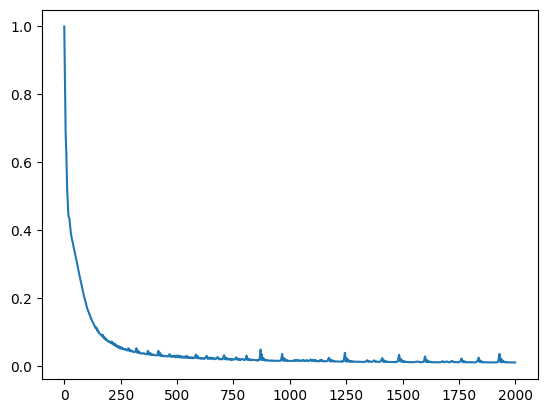

In [233]:
sns.lineplot(loss_arr)

In [234]:
with torch.no_grad():
    test_pred = model(X_test_pt)
    final_loss = loss_fn(test_pred, Y_test_pt)

print(final_loss)

tensor(1.9460)
